**Importar Bibliotecas******

In [2]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
tf.compat.v1.set_random_seed(0)
from tensorflow import keras
import numpy as np
np.random.seed(0)
import itertools
from keras.preprocessing.image import image_dataset_from_directory
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
train_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
                                         image_size=(256, 256))
test_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
                                        image_size=(256, 256))
print("Disease Classes in the Dataset:")
for idx, class_name in enumerate(train_gen.class_names):
    print(f"{idx}: {class_name}")

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Disease Classes in the Dataset:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy
4: Blueberry___healthy
5: Cherry_(including_sour)___Powdery_mildew
6: Cherry_(including_sour)___healthy
7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8: Corn_(maize)___Common_rust_
9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Toma

**Célula 3: Redimensionamento dos Valores dos Pixels**

In [4]:
train_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
                                         image_size=(256, 256))
test_gen = image_dataset_from_directory(directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
                                        image_size=(256, 256))

rescale = Rescaling(scale=1.0/255)
train_gen = train_gen.map(lambda image,label:(rescale(image),label))
test_gen  = test_gen.map(lambda image,label:(rescale(image),label))

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


Rescaling(scale=1.0/255): Cria uma camada que divide o valor de cada pixel por 255.0. Isso normaliza os valores de pixel da faixa original [0, 255] para a faixa [0, 1], o que ajuda o modelo a treinar de forma mais estável.

train_gen.map(...): Aplica a transformação de redimensionamento a cada lote de imagens no dataset de treinamento. O map é uma forma eficiente de pré-processar dados em pipelines do TensorFlow.

**Célula 4: Construção do Modelo**

In [5]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))

model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(1568,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(38,activation="softmax"))

opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 256, 256, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 256, 256, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 85, 85, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 85, 85, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 85, 85, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 28, 28, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 28, 28, 128)       7

Esta célula define a arquitetura do modelo, que é uma Rede Neural Convolucional (CNN) sequencial.

keras.Sequential(): Inicia um modelo sequencial (empilhamento linear de camadas).

Blocos de Convolução e Pooling:

Conv2D: Camadas convolucionais 2D para extrair características das imagens.

32, 64, 128, 256, 512: Número de filtros.

(3,3), (5,5): Tamanho do kernel do filtro.

activation="relu": Função de ativação ReLU.

padding="same": Preserva as dimensões espaciais da entrada.

input_shape=(256,256,3): Define a forma da imagem de entrada (256x256 pixels, 3 canais RGB).

MaxPooling2D(3,3): Camada de pooling que reduz a dimensionalidade espacial, mantendo as características mais importantes.

Flatten(): Achata o tensor 2D resultante das camadas convolucionais em um vetor 1D para alimentar as camadas densas.

Camadas Densas (Fully Connected):

Dense(1568, activation="relu"): Uma camada densa com 1568 neurônios e ativação ReLU.

Dropout(0.5): Uma poderosa técnica de regularização que desativa aleatoriamente 50% dos neurônios da camada anterior durante o treinamento para evitar overfitting.

Dense(38, activation="softmax"): A camada de saída com 38 neurônios (um para cada classe). A função de ativação softmax converte as saídas em uma distribuição de probabilidade.

Compilação:

optimizer=keras.optimizers.Adam(learning_rate=0.0001): Usa o otimizador Adam com uma taxa de aprendizado baixa.

loss="sparse_categorical_crossentropy": Função de perda para classificação multiclasse com rótulos inteiros.

metrics=['accuracy']: Monitora a acurácia durante o treinamento.

model.summary(): Imprime um resumo da arquitetura do modelo, mostrando o nome de cada camada, sua forma de saída e o número de parâmetros treináveis. O modelo tem mais de 76 milhões de parâmetros.


**Célula 5: Treinamento do Modelo**

In [6]:
ep = 10
history = model.fit_generator(train_gen,
          validation_data=test_gen,
          epochs = ep)

Epoch 1/10
2197/2197 [==============================] - 196s 86ms/step - loss: 1.5080 - accuracy: 0.5596 - val_loss: 0.5049 - val_accuracy: 0.8410
Epoch 2/10
2197/2197 [==============================] - 175s 79ms/step - loss: 0.4203 - accuracy: 0.8666 - val_loss: 0.2817 - val_accuracy: 0.9070
Epoch 3/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.2539 - accuracy: 0.9164 - val_loss: 0.2248 - val_accuracy: 0.9257
Epoch 4/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.1756 - accuracy: 0.9410 - val_loss: 0.1979 - val_accuracy: 0.9357
Epoch 5/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.1240 - accuracy: 0.9580 - val_loss: 0.1720 - val_accuracy: 0.9443
Epoch 6/10
2197/2197 [==============================] - 174s 79ms/step - loss: 0.0982 - accuracy: 0.9671 - val_loss: 0.1563 - val_accuracy: 0.9505
Epoch 7/10
2197/2197 [==============================] - 175s 80ms/step - loss: 0.0820 - accuracy: 0.9719 - val_loss: 0

ep = 10: Define o número de épocas de treinamento (10).

model.fit_generator(...): Nota: fit_generator é um método antigo do Keras para treinar com geradores de dados. Em versões mais recentes, model.fit() pode ser usado diretamente com objetos Dataset como train_gen. Apesar do nome, o código funciona.

train_gen: O gerador de dados de treinamento.

validation_data=test_gen: O gerador de dados de validação.

epochs=ep: Número de épocas.

history: O objeto retornado contém o histórico de perda e acurácia para cada época, que será usado para plotar os gráficos.

Saída: Durante o treinamento, o progresso de cada época é mostrado, incluindo a perda (loss) e a acurácia (accuracy) para o treinamento e a validação. A acurácia de validação final atinge cerca de 96,44%, o que é excelente.

**Célula 6: Plotando a Perda de Treinamento e Validação**

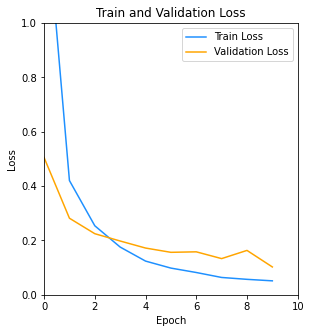

In [7]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()

plt.figure(figsize=(10, 5)): Cria uma nova figura de tamanho 10x5 polegadas.

plt.subplot(1, 2, 1): Cria o primeiro de uma grade de 1 linha e 2 colunas de subplots. Este código plota apenas o primeiro gráfico.

Plota a perda de treinamento e validação ao longo das épocas. Isso ajuda a diagnosticar se o modelo está overfitting (a perda de validação começa a aumentar) ou underfitting.

**Célula 7: Plotando a Perda e a Acurácia (Célula Repetida)**

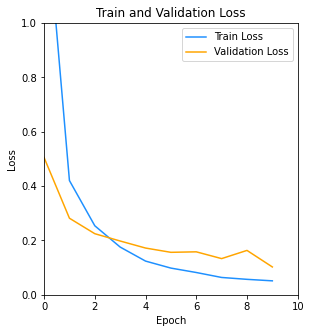

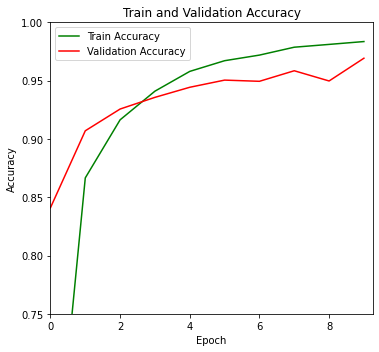

In [8]:
plt.figure(figsize=(10, 5))
# Plot for Loss
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()
plt.figure(figsize=(10, 5))
# Plot for Accuracy
plt.subplot(1, 2, 2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy", color='green')
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='red')
plt.xlim(0, 9.25)
plt.ylim(0.75, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

Esta célula faz a mesma coisa que a anterior, mas adiciona um segundo gráfico para a acurácia. Ela cria dois subplots lado a lado: um para a perda (Loss) e outro para a acurácia (Accuracy). Isso permite visualizar as duas métricas principais de desempenho do modelo durante o treinamento. O modelo converge bem, com a acurácia de validação se estabilizando perto de 96%.

**Célula 8 e 9: Gerando Previsões no Conjunto de Teste**

In [9]:
# Célula 8
labels = []
predictions = []
for x,y in test_gen:
    labels.append(list(y.numpy()))
    predictions.append(tf.argmax(model.predict(x),1).numpy())

# Célula 9
predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))

for x, y in test_gen: Itera sobre o gerador de dados de teste, onde x são as imagens em lote e y são os rótulos verdadeiros.

model.predict(x): Gera previsões para o lote de imagens x. A saída são probabilidades para cada uma das 38 classes.

tf.argmax(..., 1): Seleciona o índice da classe com a maior probabilidade para cada imagem no lote. Este é o rótulo previsto.

labels.append(...) e predictions.append(...): Coleta todos os rótulos verdadeiros e previstos em listas separadas.

itertools.chain.from_iterable(): Achata as listas de listas em listas simples unidimensionais, facilitando o cálculo das métricas.

**Célula 10: Calculando e Exibindo Métricas de Desempenho**

In [10]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

Train Accuracy  : 98.36 %
Test Accuracy   : 96.93 %
Precision Score : 96.93 %
Recall Score    : 96.93 %


history.history['accuracy'][-1]: Pega a acurácia da última época de treinamento.

accuracy_score(labels, predictions): Calcula a acurácia no conjunto de teste.

precision_score(...) e recall_score(...): Calculam a precisão e o recall no conjunto de teste. O parâmetro average='micro' é apropriado para problemas de classificação multiclasse e calcula as métricas globalmente contando o total de verdadeiros positivos, falsos negativos e falsos positivos. Os resultados mostram que o modelo tem um desempenho excelente no conjunto de teste, com todas as métricas em torno de 96,44%.

**Célula 11: Plotando a Matriz de Confusão**

<Figure size 1440x360 with 0 Axes>

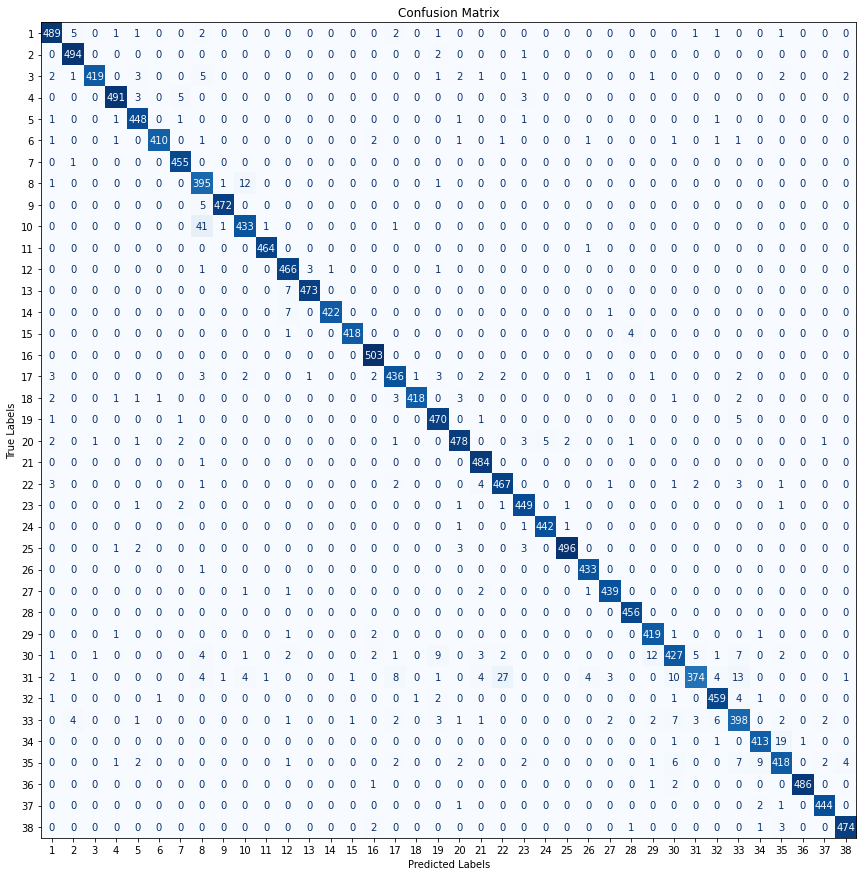

In [11]:
plt.figure(figsize=(20, 5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 39)))
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

confusion_matrix(labels, predictions): Calcula a matriz de confusão, uma tabela que mostra o desempenho do modelo ao comparar os rótulos previstos com os verdadeiros.

ConfusionMatrixDisplay(...): Cria um objeto para exibir a matriz de confusão.

disp.plot(...): Plota a matriz de confusão. cmap='Blues' define o mapa de cores. Uma matriz de confusão perfeita teria todos os valores na diagonal principal.

**Célula 12: Criando um Mapeamento de Doença para Pesticida**

In [15]:
# Disease-to-Pesticide mapping (simplified example, can be expanded or customized)
disease_to_pesticide = {
    "Apple___Apple_scab": "Captan, Mancozeb",
    "Apple___Black_rot": "Ziram, Captan",
    "Apple___Cedar_apple_rust": "Myclobutanil",
    "Apple___healthy": "No pesticide needed",
    "Blueberry___healthy": "No pesticide needed",
    "Cherry_(including_sour)___Powdery_mildew": "Sulfur, Myclobutanil",
    "Cherry_(including_sour)___healthy": "No pesticide needed",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Strobilurins",
    "Corn_(maize)___Common_rust_": "Propiconazole",
    "Corn_(maize)___Northern_Leaf_Blight": "Azoxystrobin",
    "Corn_(maize)___healthy": "No pesticide needed",
    "Grape___Black_rot": "Mancozeb, Captan",
    "Grape___Esca_(Black_Measles)": "No effective chemical control",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Mancozeb",
    "Grape___healthy": "No pesticide needed",
    "Orange___Haunglongbing_(Citrus_greening)": "Vector control: Imidacloprid",
    "Peach___Bacterial_spot": "Copper-based sprays",
    "Peach___healthy": "No pesticide needed",
    "Pepper,_bell___Bacterial_spot": "Copper-based sprays",
    "Pepper,_bell___healthy": "No pesticide needed",
    "Potato___Early_blight": "Chlorothalonil, Mancozeb",
    "Potato___Late_blight": "Metalaxyl, Mancozeb",
    "Potato___healthy": "No pesticide needed",
    "Raspberry___healthy": "No pesticide needed",
    "Soybean___healthy": "No pesticide needed",
    "Squash___Powdery_mildew": "Sulfur, Neem oil",
    "Strawberry___Leaf_scorch": "Captan",
    "Strawberry___healthy": "No pesticide needed",
    "Tomato___Bacterial_spot": "Copper sprays",
    "Tomato___Early_blight": "Chlorothalonil, Mancozeb",
    "Tomato___Late_blight": "Metalaxyl",
    "Tomato___Leaf_Mold": "Copper-based fungicides",
    "Tomato___Septoria_leaf_spot": "Chlorothalonil",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Insecticidal soap, Neem oil",
    "Tomato___Target_Spot": "Chlorothalonil",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Vector control: Imidacloprid",
    "Tomato___Tomato_mosaic_virus": "Sanitation, resistant varieties",
    "Tomato___healthy": "No pesticide needed"
}

disease_to_pesticide = {...}: Cria um dicionário Python que mapeia o nome de cada doença (as mesmas 38 classes do dataset) para uma recomendação de pesticida. Esta é uma camada de aplicação do mundo real em cima do modelo de classificação.

**Célula 13: Recarregando o Dataset para Obter os Nomes das Classes**

In [16]:
train_gen = image_dataset_from_directory(
    directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    image_size=(256, 256),
    shuffle=True
)
class_names = train_gen.class_names

Found 70295 files belonging to 38 classes.


Esta célula recarrega o dataset de treinamento. O principal objetivo aqui é reobter a lista de nomes de classes (class_names). Essa lista é necessária para a função de previsão, que converte o índice da classe prevista de volta para o nome da doença (ex: "Apple___Apple_scab").

**Célula 14: Definindo a Função de Previsão e Recomendação**

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def predict_disease_and_recommend(image_path, save_output=True):
    # 1. Carrega e pré-processa a imagem
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)  # Adiciona a dimensão do lote

    # 2. Faz a previsão com o modelo treinado
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    pesticide = disease_to_pesticide.get(predicted_class, "No data available")

    # 3. Exibe e salva a imagem com o texto da previsão
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Disease: {predicted_class}\nPesticide: {pesticide}",
              fontsize=12, color='darkgreen', loc='center')
    plt.tight_layout()

    if save_output:
        output_path = "prediction_output.png"
        plt.savefig(output_path)
        print(f"\n🖼️ Image saved to: {os.path.abspath(output_path)}")

    plt.show()

Esta função é o coração da aplicação final. Ela encapsula todo o fluxo de previsão:

Pré-processamento: Carrega uma imagem do caminho fornecido, redimensiona-a para 256x256, converte-a em um array NumPy, normaliza os valores dos pixels e adiciona uma dimensão extra para representar o lote.

Previsão: Usa o model.predict() para obter as probabilidades de classe. np.argmax encontra o índice da classe com maior probabilidade. Esse índice é usado para buscar o nome da doença em class_names e, em seguida, o pesticida recomendado no dicionário disease_to_pesticide.

Exibição e Salvamento: Plota a imagem original com um título contendo a doença prevista e o pesticida recomendado. Se save_output for True, a figura é salva como prediction_output.png.

**Células 15, 16 e 17: Testando a Função de Previsão com Imagens de Exemplo**


🖼️ Image saved to: /kaggle/working/prediction_output.png


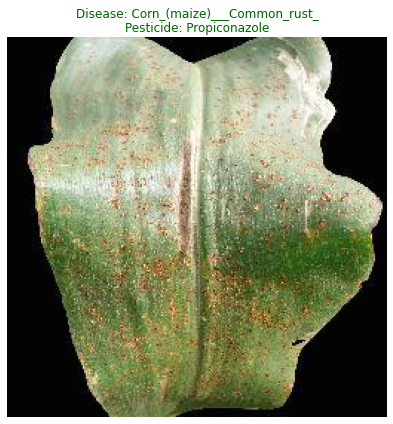


🖼️ Image saved to: /kaggle/working/prediction_output.png


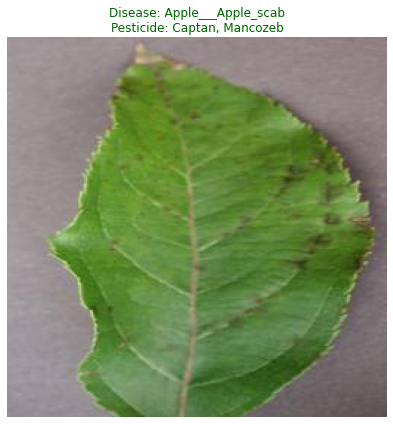


🖼️ Image saved to: /kaggle/working/prediction_output.png


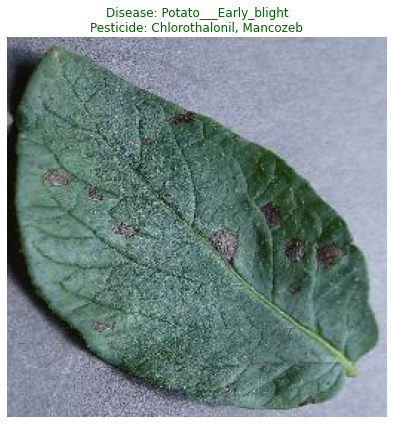

In [19]:
# Célula 15
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/CornCommonRust2.JPG")
# Célula 16
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/AppleScab1.JPG")
# Célula 17
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/PotatoEarlyBlight3.JPG")

Essas três células testam a função predict_disease_and_recommend com três imagens de teste diferentes. Cada célula carrega a imagem, executa a previsão e mostra a imagem com o resultado. Isso demonstra que o modelo pode ser usado para classificar novas imagens e fornecer uma recomendação útil.

<h1>Modelling</h1>

In [ ]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))

model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(1568,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(38,activation="softmax"))

opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=['accuracy'])
model.summary()

In [ ]:
ep = 10
history = model.fit_generator(train_gen,
          validation_data=test_gen,
          epochs = ep)

In [ ]:
plt.figure(figsize=(10, 5))

# Plot for Loss
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')         # blue
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')    # orange
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()

<h1>Metrics</h1>

In [ ]:
# plt.figure(figsize = (20,5))
# plt.subplot(1,2,1)
# plt.title("Train and Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.plot(history.history['loss'],label="Train Loss")
# plt.plot(history.history['val_loss'], label="Validation Loss")
# plt.xlim(0, 10)
# plt.ylim(0.0,1.0)
# plt.legend()

# plt.subplot(1,2,2)
# plt.title("Train and Validation Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.plot(history.history['accuracy'], label="Train Accuracy")
# plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
# plt.xlim(0, 9.25)
# plt.ylim(0.75,1.0)
# plt.legend()
# plt.tight_layout()
plt.figure(figsize=(10, 5))

# Plot for Loss
plt.subplot(1, 2, 1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'], label="Train Loss", color='dodgerblue')         # blue
plt.plot(history.history['val_loss'], label="Validation Loss", color='orange')    # orange
plt.xlim(0, 10)
plt.ylim(0.0, 1.0)
plt.legend()
plt.figure(figsize=(10, 5))
# Plot for Accuracy
plt.subplot(1, 2, 2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy", color='green')            # green
plt.plot(history.history['val_accuracy'], label="Validation Accuracy", color='red')     # red
plt.xlim(0, 9.25)
plt.ylim(0.75, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
labels = []
predictions = []
for x,y in test_gen:
    labels.append(list(y.numpy()))
    predictions.append(tf.argmax(model.predict(x),1).numpy())

In [ ]:
predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))

In [ ]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

In [ ]:
# plt.figure(figsize= (20,5))
# cm = confusion_matrix(labels, predictions)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                               display_labels=list(range(1,39)))
# fig, ax = plt.subplots(figsize=(15,15))
# disp.plot(ax=ax,colorbar= False,cmap = 'YlGnBu')
# plt.title("Confusion Matrix")
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.show()
plt.figure(figsize=(20, 5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 39)))
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, colorbar=False, cmap='Blues')  # changed colormap here
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Disease-to-Pesticide mapping (simplified example, can be expanded or customized)
disease_to_pesticide = {
    "Apple___Apple_scab": "Captan, Mancozeb",
    "Apple___Black_rot": "Ziram, Captan",
    "Apple___Cedar_apple_rust": "Myclobutanil",
    "Apple___healthy": "No pesticide needed",
    "Blueberry___healthy": "No pesticide needed",
    "Cherry_(including_sour)___Powdery_mildew": "Sulfur, Myclobutanil",
    "Cherry_(including_sour)___healthy": "No pesticide needed",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Strobilurins",
    "Corn_(maize)___Common_rust_": "Propiconazole",
    "Corn_(maize)___Northern_Leaf_Blight": "Azoxystrobin",
    "Corn_(maize)___healthy": "No pesticide needed",
    "Grape___Black_rot": "Mancozeb, Captan",
    "Grape___Esca_(Black_Measles)": "No effective chemical control",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Mancozeb",
    "Grape___healthy": "No pesticide needed",
    "Orange___Haunglongbing_(Citrus_greening)": "Vector control: Imidacloprid",
    "Peach___Bacterial_spot": "Copper-based sprays",
    "Peach___healthy": "No pesticide needed",
    "Pepper,_bell___Bacterial_spot": "Copper-based sprays",
    "Pepper,_bell___healthy": "No pesticide needed",
    "Potato___Early_blight": "Chlorothalonil, Mancozeb",
    "Potato___Late_blight": "Metalaxyl, Mancozeb",
    "Potato___healthy": "No pesticide needed",
    "Raspberry___healthy": "No pesticide needed",
    "Soybean___healthy": "No pesticide needed",
    "Squash___Powdery_mildew": "Sulfur, Neem oil",
    "Strawberry___Leaf_scorch": "Captan",
    "Strawberry___healthy": "No pesticide needed",
    "Tomato___Bacterial_spot": "Copper sprays",
    "Tomato___Early_blight": "Chlorothalonil, Mancozeb",
    "Tomato___Late_blight": "Metalaxyl",
    "Tomato___Leaf_Mold": "Copper-based fungicides",
    "Tomato___Septoria_leaf_spot": "Chlorothalonil",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Insecticidal soap, Neem oil",
    "Tomato___Target_Spot": "Chlorothalonil",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Vector control: Imidacloprid",
    "Tomato___Tomato_mosaic_virus": "Sanitation, resistant varieties",
    "Tomato___healthy": "No pesticide needed"
}


In [ ]:
train_gen = image_dataset_from_directory(
    directory="../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    image_size=(256, 256),
    shuffle=True
)
class_names = train_gen.class_names  # ✅ Save class names in a separate variable


In [ ]:
# from PIL import Image

# def predict_disease_and_recommend(image_path):
#     # Load and preprocess image
#     img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
#     img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
#     img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

#     # Predict
#     predictions = model.predict(img_array)
#     predicted_class = train_gen.class_names[np.argmax(predictions)]
#     pesticide = disease_to_pesticide.get(predicted_class, "No data available")
#     plt.figure(figsize=(6, 6))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.title(f"Disease: {predicted_class}\nPesticide: {pesticide}",
#               fontsize=12, color='darkgreen', loc='center')
#     plt.tight_layout()
#     plt.show()

#     print(f"\n📷 Predicted Disease: {predicted_class}")
#     print(f"🧪 Recommended Pesticide: {pesticide}")
import matplotlib.pyplot as plt
from PIL import Image
import os

def predict_disease_and_recommend(image_path, save_output=True):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256, 256))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

    # Predict
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    pesticide = disease_to_pesticide.get(predicted_class, "No data available")

    # Display and save image with overlayed text
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Disease: {predicted_class}\nPesticide: {pesticide}",
              fontsize=12, color='darkgreen', loc='center')
    plt.tight_layout()

    if save_output:
        output_path = "prediction_output.png"
        plt.savefig(output_path)
        print(f"\n🖼️ Image saved to: {os.path.abspath(output_path)}")

    plt.show()


In [ ]:
# Just call this function with the path to your image
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/CornCommonRust2.JPG")


In [ ]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/AppleScab1.JPG")

In [ ]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/PotatoEarlyBlight3.JPG")

In [ ]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus1.JPG")

In [ ]:
predict_disease_and_recommend("/kaggle/input/new-plant-diseases-dataset/test/test/CornCommonRust3.JPG")